# 🚗 Car Evaluation Classification — Decision Tree

**🇹🇷 Türkçe:**
Bu notebook, bir aracın satın alma fiyatı, bakım maliyeti, kapı sayısı, kapasite, bagaj hacmi ve güvenlik seviyesi gibi kategorik özelliklerinden genel değerlendirmesini (`class`: `unacc`, `acc`, `good`, `vgood`) tahmin eden bir Karar Ağacı (Decision Tree) sınıflandırıcısı kuruyor.

Notebook iki aşamalı ilerliyor: önce sabit hiperparametrelerle (`max_depth=3`) kurulan basit bir ağaç, ardından `GridSearchCV` ile hiperparametre araması yapılmış bir ağaç. İkisi arasındaki fark, tek bir ağacın ne kadar sığ kalabileceğini ve aramanın nasıl büyük bir doğruluk kazancına dönüştüğünü gösteriyor.

**🇬🇧 English:**
This notebook builds a Decision Tree classifier that predicts a car's overall evaluation (`class`: `unacc`, `acc`, `good`, `vgood`) from categorical attributes such as buying price, maintenance cost, number of doors, passenger capacity, luggage boot size, and safety level.

The notebook proceeds in two stages: first a simple tree built with fixed hyperparameters (`max_depth=3`), then a tree tuned via `GridSearchCV`. The gap between the two shows how shallow a single fixed tree can be, and how much accuracy a systematic search can recover.

## 📦 0. Kütüphaneler / Imports

**🇹🇷 Türkçe:**
Veri işleme, görselleştirme ve modelleme için gerekli kütüphaneler tek hücrede toplanıyor.

**🇬🇧 English:**
The libraries needed for data handling, visualization, and modeling are collected in a single cell.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📥 1. Veri Setini Yükleme / Load the Dataset

**🇹🇷 Türkçe:**
Car Evaluation veri seti yükleniyor. Ham dosyada kolon başlıkları yok, bu yüzden `df.columns` ile isimler manuel atanıyor: `buying`, `maint`, `doors`, `persons`, `lug_boot`, `safety` (özellikler) ve `class` (hedef değişken).

**🇬🇧 English:**
The Car Evaluation dataset is loaded. The raw file has no column headers, so names are assigned manually via `df.columns`: `buying`, `maint`, `doors`, `persons`, `lug_boot`, `safety` (features) and `class` (target).

In [2]:
df = pd.read_csv("../../Data/13-car_evaluation.csv")

In [3]:
col_names = ["buying", "maint", "doors", "persons", "lug_boot","safety","class"]

In [4]:
df.columns = col_names

In [5]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


## 🔍 2. Veriye İlk Bakış / First Look at the Data

**🇹🇷 Türkçe:**
`info()`, `describe()`, eksik değer ve kopya satır kontrolleri ile veri setinin genel sağlığı doğrulanıyor. Tüm kolonlar kategorik (`str`/`object`) — bu, modele girmeden önce sayısal bir forma dönüştürülmeleri gerektiği anlamına gelir.

**🇬🇧 English:**
`info()`, `describe()`, and checks for missing values and duplicate rows confirm the overall health of the dataset. Every column is categorical (`str`/`object`) — meaning they must be converted to a numeric form before they can be fed into the model.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1727 non-null   str  
 1   maint     1727 non-null   str  
 2   doors     1727 non-null   str  
 3   persons   1727 non-null   str  
 4   lug_boot  1727 non-null   str  
 5   safety    1727 non-null   str  
 6   class     1727 non-null   str  
dtypes: str(7)
memory usage: 94.6 KB


In [7]:
df.describe()

,buying,maint,doors,persons,lug_boot,safety,class
count,1727,1727,1727,1727,1727,1727,1727
unique,4,4,4,3,3,3,4
top,high,high,3,4,med,med,unacc
freq,432,432,432,576,576,576,1209


In [8]:
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

## 🔠 3. Kategori Değerlerini İnceleme / Inspecting Category Values

**🇹🇷 Türkçe:**
Her kolonun aldığı benzersiz değerler ve bu değerlerin dağılımı (`value_counts`) inceleniyor. `doors` ve `persons` kolonlarının aslında sayısal bir sıralama taşıdığı (`'5more'`, `'more'` gibi metin değerleri dışında) burada fark ediliyor — bu gözlem bir sonraki adımdaki dönüşümü yönlendiriyor.

**🇬🇧 English:**
The unique values of each column and their distribution (`value_counts`) are inspected. It becomes clear that `doors` and `persons` actually carry a numeric ordering (aside from text values like `'5more'` and `'more'`) — this observation drives the conversion in the next step.

In [10]:
df["buying"].unique()

<StringArray>
['vhigh', 'high', 'med', 'low']
Length: 4, dtype: str

In [11]:
df["maint"].unique()

<StringArray>
['vhigh', 'high', 'med', 'low']
Length: 4, dtype: str

In [12]:
df["doors"].unique()

<StringArray>
['2', '3', '4', '5more']
Length: 4, dtype: str

In [13]:
for col in df.columns:
    print(df[col].value_counts())

buying
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
maint
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
doors
3        432
4        432
5more    432
2        431
Name: count, dtype: int64
persons
4       576
more    576
2       575
Name: count, dtype: int64
lug_boot
med      576
big      576
small    575
Name: count, dtype: int64
safety
med     576
high    576
low     575
Name: count, dtype: int64
class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [14]:
for col in df.columns:
    print(col, df[col].unique())

buying <StringArray>
['vhigh', 'high', 'med', 'low']
Length: 4, dtype: str
maint <StringArray>
['vhigh', 'high', 'med', 'low']
Length: 4, dtype: str
doors <StringArray>
['2', '3', '4', '5more']
Length: 4, dtype: str
persons <StringArray>
['2', '4', 'more']
Length: 3, dtype: str
lug_boot <StringArray>
['small', 'med', 'big']
Length: 3, dtype: str
safety <StringArray>
['med', 'high', 'low']
Length: 3, dtype: str
class <StringArray>
['unacc', 'acc', 'vgood', 'good']
Length: 4, dtype: str


## 🔧 4. `doors` ve `persons` Kolonlarını Sayısallaştırma / Converting `doors` and `persons` to Numeric

**🇹🇷 Türkçe:**
`doors` kolonundaki `'5more'` değeri `'5'` ile, `persons` kolonundaki `'more'` değeri `'5'` ile değiştirilip her iki kolon `int` tipine dönüştürülüyor. Böylece bu iki kolon artık gerçek bir sıralamayı yansıtan sayısal değerler taşıyor; `buying`, `maint`, `lug_boot`, `safety` gibi doğal bir sayısal karşılığı olmayan kolonlar ise kategorik kalıyor ve ileride ayrı şekilde kodlanacak.

**🇬🇧 English:**
The value `'5more'` in `doors` and `'more'` in `persons` are replaced with `'5'`, and both columns are cast to `int`. These two columns now carry numeric values that reflect a real ordering, while columns without a natural numeric equivalent — `buying`, `maint`, `lug_boot`, `safety` — remain categorical and will be encoded separately later.

In [15]:
df["doors"] = df["doors"].replace("5more", "5")

In [16]:
df["doors"] = df["doors"].astype(int)

In [17]:
df["persons"] = df["persons"].replace("more", "5")

In [18]:
df["persons"] = df["persons"].astype(int)

## 📈 5. Görselleştirme / Visualization

**🇹🇷 Türkçe:**
`lug_boot` ve `buying` arasındaki ilişki, `class` etiketine göre renklendirilerek inceleniyor.

**🇬🇧 English:**
The relationship between `lug_boot` and `buying` is inspected, colored by the `class` label.

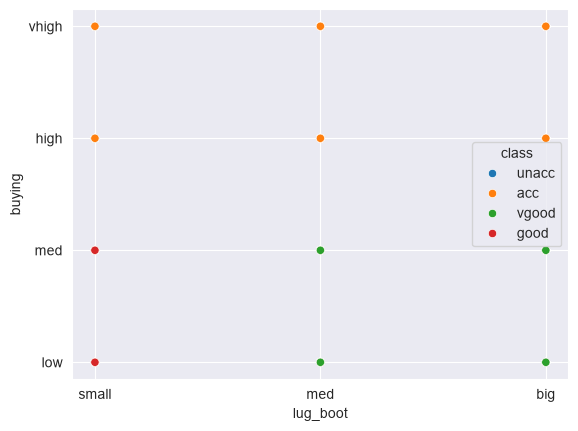

In [19]:
sns.scatterplot(x=df["lug_boot"],y=df["buying"] , hue=df["class"])
plt.show()

## ✂️ 6. Özellik/Hedef Ayrımı ve Train-Test Bölme / Feature-Target Split and Train-Test Split

**🇹🇷 Türkçe:**
`X` (özellikler) ve `y` (hedef) ayrılıyor, ardından veri eğitim ve test setlerine bölünüyor. Bölme, kodlama adımından **önce** yapılıyor — böylece `OrdinalEncoder` istatistikleri yalnızca eğitim verisinden öğrenilecek ve test setinden bilgi sızıntısı olmayacak.

**🇬🇧 English:**
`X` (features) and `y` (target) are separated, then the data is split into training and test sets. The split happens **before** encoding, so `OrdinalEncoder` statistics will be learned from the training data only and no information leaks from the test set.

In [20]:
X = df.drop("class",axis=1)
y = df["class"]
pipe_col = X.columns.tolist()

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 15)

In [23]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [24]:
for col in df.columns:
    print(df[col].unique())

<StringArray>
['vhigh', 'high', 'med', 'low']
Length: 4, dtype: str
<StringArray>
['vhigh', 'high', 'med', 'low']
Length: 4, dtype: str
[2 3 4 5]
[2 4 5]
<StringArray>
['small', 'med', 'big']
Length: 3, dtype: str
<StringArray>
['med', 'high', 'low']
Length: 3, dtype: str
<StringArray>
['unacc', 'acc', 'vgood', 'good']
Length: 4, dtype: str


In [25]:
for col in df.columns:
    print(df[col].value_counts())

buying
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
maint
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
doors
3    432
4    432
5    432
2    431
Name: count, dtype: int64
persons
4    576
5    576
2    575
Name: count, dtype: int64
lug_boot
med      576
big      576
small    575
Name: count, dtype: int64
safety
med     576
high    576
low     575
Name: count, dtype: int64
class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64


## 🔢 7. Sıralı Kodlama / Ordinal Encoding

**🇹🇷 Türkçe:**
`buying`, `maint`, `lug_boot`, `safety` kolonları doğal bir sıralamaya sahip (örn. `low < med < high < vhigh`), bu yüzden `OneHotEncoder` yerine bu sırayı koruyan `OrdinalEncoder` tercih ediliyor. Sıralama, `categories` parametresiyle elle belirtiliyor — aksi halde encoder alfabetik sıraya göre kodlama yapardı ki bu, `high`'ı `low`'dan küçük bir sayıya eşlerdi.

Kodlama, `ColumnTransformer` içinde tanımlanıp yalnızca eğitim setine `fit_transform`, test setine ise `transform` uygulanıyor — bu da sızıntısız bir ön işleme sağlıyor.

**🇬🇧 English:**
`buying`, `maint`, `lug_boot`, and `safety` have a natural ordering (e.g. `low < med < high < vhigh`), so `OrdinalEncoder` is used instead of `OneHotEncoder` to preserve that order. The order is specified explicitly via the `categories` parameter — otherwise the encoder would default to alphabetical order, which would map `high` to a smaller number than `low`.

The encoding is wrapped in a `ColumnTransformer` and fit only on the training set (`fit_transform`), then applied to the test set with `transform` — keeping the preprocessing leakage-free.

In [26]:
cat_cols = ["buying","maint","lug_boot","safety"]
num_cols = ["doors","persons"]

ord_enc = OrdinalEncoder(categories = [
    ["low","med","high","vhigh"],
    ["low","med","high","vhigh"],
    ["small","med","big"],
    ["low","med","high"]
])
preprocessor = ColumnTransformer([("num", ord_enc, cat_cols)], remainder = "passthrough")
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

## 🌳 8. İlk Model — Sabit Hiperparametreli Karar Ağacı / Baseline Model — Fixed-Hyperparameter Decision Tree

**🇹🇷 Türkçe:**
`max_depth=3` gibi elle seçilmiş, sığ bir ağaç eğitiliyor. Bu, bir sonraki bölümdeki `GridSearchCV` araması için bir karşılaştırma noktası (baseline) oluşturuyor.

**🇬🇧 English:**
A shallow tree with a hand-picked `max_depth=3` is trained. This provides a baseline to compare against the `GridSearchCV` search performed later.

In [27]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(criterion="gini",max_depth=3,random_state=0)
tree_model.fit(X_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at t

## 📊 9. Baseline Model Değerlendirmesi / Baseline Model Evaluation

**🇹🇷 Türkçe:**
Karışıklık matrisi ve `classification_report` ile model değerlendiriliyor. Sonuç %79 doğruluk gösteriyor ama bu sayı yanıltıcı: `good` ve `vgood` sınıflarında precision/recall **0**. `max_depth=3` kısıtı, ağacın azınlık sınıflarını ayırt edecek kadar derinleşmesine izin vermiyor — model bunun yerine çoğunluk sınıfı `unacc`'a yaslanıyor.

**🇬🇧 English:**
The model is evaluated with a confusion matrix and `classification_report`. The result shows 79% accuracy, but that number is misleading: precision/recall for the `good` and `vgood` classes are **0**. The `max_depth=3` constraint doesn't let the tree grow deep enough to separate the minority classes — instead the model leans on the majority class, `unacc`.

In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [29]:
y_pred = tree_model.predict(X_test)

In [30]:
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[ 44   0  49   0]
 [ 19   0   0   0]
 [  8   0 297   0]
 [ 15   0   0   0]]
              precision    recall  f1-score   support

         acc       0.51      0.47      0.49        93
        good       0.00      0.00      0.00        19
       unacc       0.86      0.97      0.91       305
       vgood       0.00      0.00      0.00        15

    accuracy                           0.79       432
   macro avg       0.34      0.36      0.35       432
weighted avg       0.72      0.79      0.75       432

0.7893518518518519


C:\Users\efeka\PycharmProjects\PythonProject1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\efeka\PycharmProjects\PythonProject1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\efeka\PycharmProjects\PythonProject1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

## 🌲 10. Ağacı Görselleştirme / Visualizing the Tree

**🇹🇷 Türkçe:**
`plot_tree` ile ağacın karar mantığı görselleştiriliyor — `max_depth=3` sınırı yüzünden yalnızca birkaç bölünme (split) içeren sığ bir yapı görülüyor.

**🇬🇧 English:**
`plot_tree` visualizes the tree's decision logic — because of the `max_depth=3` limit, this shows a shallow structure with only a handful of splits.

[Text(0.3333333333333333, 0.875, 'safety <= 0.5\ngini = 0.459\nsamples = 1295\nvalue = [291, 50, 904, 50]'),
 Text(0.16666666666666666, 0.625, 'gini = 0.0\nsamples = 436\nvalue = [0, 0, 436, 0]'),
 Text(0.25, 0.75, 'True  '),
 Text(0.5, 0.625, 'persons <= 3.0\ngini = 0.582\nsamples = 859\nvalue = [291.0, 50.0, 468.0, 50.0]'),
 Text(0.41666666666666663, 0.75, '  False'),
 Text(0.3333333333333333, 0.375, 'gini = 0.0\nsamples = 281\nvalue = [0, 0, 281, 0]'),
 Text(0.6666666666666666, 0.375, 'buying <= 1.5\ngini = 0.627\nsamples = 578\nvalue = [291.0, 50.0, 187.0, 50.0]'),
 Text(0.5, 0.125, 'gini = 0.639\nsamples = 298\nvalue = [160, 50, 38, 50]'),
 Text(0.8333333333333334, 0.125, 'gini = 0.498\nsamples = 280\nvalue = [131, 0, 149, 0]')]

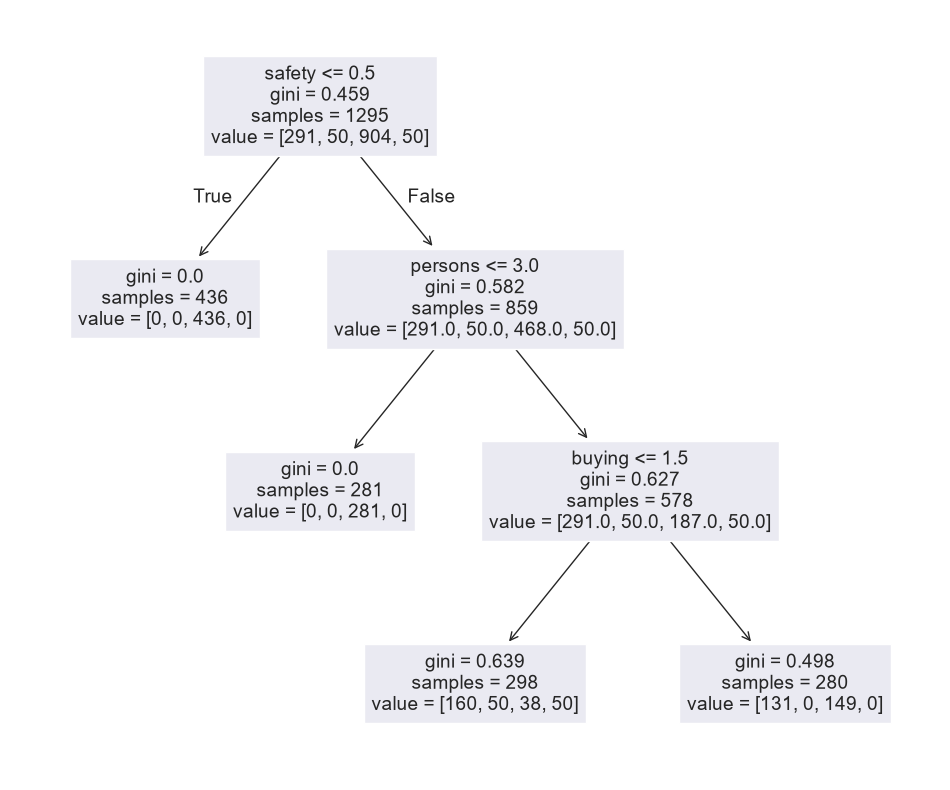

In [31]:
plt.figure(figsize=(12,10))

columns_names = cat_cols + num_cols

from sklearn import tree

tree.plot_tree(tree_model.fit(X_train,y_train),feature_names=columns_names)

## 🔎 11. Hiperparametre Optimizasyonu / Hyperparameter Tuning

**🇹🇷 Türkçe:**
`GridSearchCV` ile `criterion`, `splitter`, `max_depth` ve `max_features` parametreleri 5 katlı çapraz doğrulama üzerinden taranıyor. `max_depth` ızgarasına `None` (sınırsız derinlik) de dahil edildi — bu, baseline modelin tersine ağacın azınlık sınıflarını ayırt edecek kadar büyümesine izin verip vermeyeceğini test ediyor.

**🇬🇧 English:**
`GridSearchCV` searches over `criterion`, `splitter`, `max_depth`, and `max_features` with 5-fold cross-validation. The `max_depth` grid includes `None` (unlimited depth) — unlike the baseline, this tests whether letting the tree grow deep enough helps it separate the minority classes.

In [32]:
from sklearn.model_selection import GridSearchCV

In [41]:
param = {
    "criterion": ["gini", "entropy"],
    "splitter": ["best", "random"],
    "max_depth": [3,5,7,9,None],
    "max_features": ["sqrt", "log2",None],
}

In [42]:
grid = GridSearchCV(estimator=tree_model, param_grid=param, scoring="accuracy", cv=5)

In [53]:
grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'splitter': ['best', 'random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added

In [54]:
grid.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'splitter': 'best'}

## 📊 12. Tune Edilmiş Model Değerlendirmesi / Tuned Model Evaluation

**🇹🇷 Türkçe:**
En iyi parametrelerle (`max_depth=None`, sınırsız derinlik) tahmin yapılıp aynı metriklerle değerlendiriliyor. Sonuç %98.4 doğruluk — baseline'a göre 19 puanlık bir kazanç. Daha önemlisi, `good` ve `vgood` sınıflarında artık precision/recall **0 değil**: ağacın derinleşmesine izin vermek, tam olarak baseline'ın kaçırdığı azınlık sınıflarını yakalıyor.

**🇬🇧 English:**
Predictions are made with the best parameters (`max_depth=None`, unlimited depth) and evaluated with the same metrics. The result is 98.4% accuracy — a 19-point gain over the baseline. More importantly, precision/recall for `good` and `vgood` are **no longer 0**: letting the tree grow deep enough captures exactly the minority classes the baseline missed.

In [55]:
y_pred_new = grid.predict(X_test)

In [51]:
print(confusion_matrix(y_test,y_pred_new))
print(classification_report(y_test,y_pred_new))
print(accuracy_score(y_test,y_pred_new))

[[ 91   0   1   1]
 [  3  16   0   0]
 [  2   0 303   0]
 [  0   0   0  15]]
              precision    recall  f1-score   support

         acc       0.95      0.98      0.96        93
        good       1.00      0.84      0.91        19
       unacc       1.00      0.99      1.00       305
       vgood       0.94      1.00      0.97        15

    accuracy                           0.98       432
   macro avg       0.97      0.95      0.96       432
weighted avg       0.98      0.98      0.98       432

0.9837962962962963


## 🌲 13. Nihai Ağacı Görselleştirme / Visualizing the Final Tree

**🇹🇷 Türkçe:**
En iyi parametrelerle yeniden eğitilmiş ağaç görselleştiriliyor. Baseline'daki sığ yapının aksine, burada belirgin şekilde daha derin ve dallanmış bir ağaç görülüyor — yüksek doğruluğun kaynağı bu ek derinlik.

**🇬🇧 English:**
The tree retrained with the best parameters is visualized. In contrast to the shallow baseline structure, this shows a noticeably deeper, more branched tree — that extra depth is the source of the higher accuracy.

In [56]:
tree_model_new = DecisionTreeClassifier(criterion="entropy",max_depth=None,max_features=None,splitter="best")

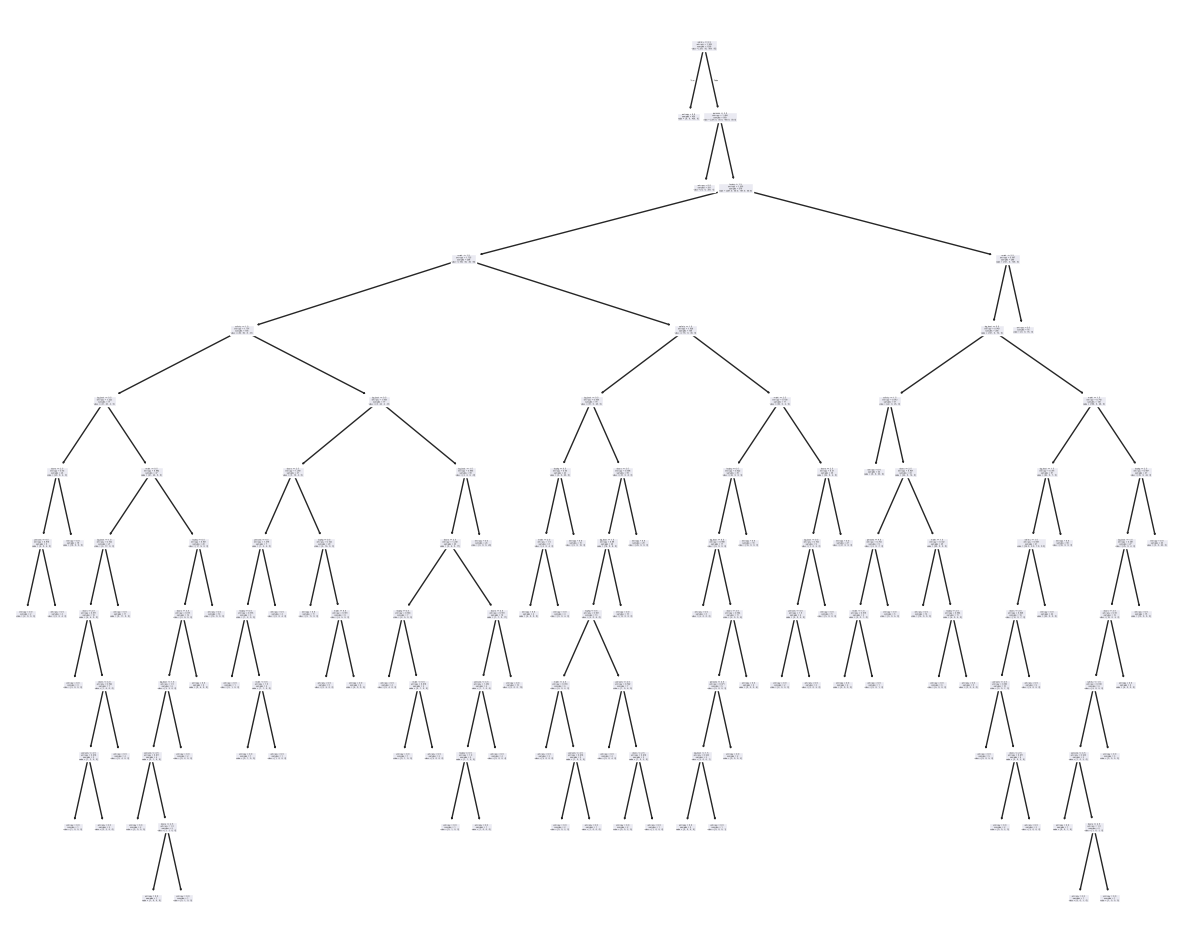

In [59]:
plt.figure(figsize=(15,12))
tree.plot_tree(tree_model_new.fit(X_train,y_train),feature_names=columns_names)
plt.show()

## ✅ 14. Sonuç / Conclusion

**🇹🇷 Türkçe:**
- Sabit `max_depth=3` ile eğitilen baseline ağaç %79 doğruluk verdi, ancak `good`/`vgood` azınlık sınıflarını tamamen kaçırdı (precision/recall = 0).
- `GridSearchCV` ile `criterion`, `splitter`, `max_depth` ve `max_features` üzerinde 5 katlı çapraz doğrulama araması yapıldı; en iyi kombinasyon sınırsız derinlik (`max_depth=None`) oldu.
- Tune edilmiş ağaç **%98.4** doğruluğa ulaştı ve tüm sınıflarda (azınlık sınıflar dahil) yüksek precision/recall gösterdi.
- Ders: Karar ağaçlarında sığ bir derinlik sınırı, dengesiz sınıflı veri setlerinde azınlık sınıflarını görünmez kılabilir; hiperparametre araması bu tür körlükleri ortaya çıkarabilir.

**🇬🇧 English:**
- The baseline tree trained with a fixed `max_depth=3` reached 79% accuracy but completely missed the `good`/`vgood` minority classes (precision/recall = 0).
- `GridSearchCV` searched over `criterion`, `splitter`, `max_depth`, and `max_features` with 5-fold cross-validation; the best combination was unlimited depth (`max_depth=None`).
- The tuned tree reached **98.4%** accuracy with strong precision/recall across every class, including the minority ones.
- Takeaway: a shallow fixed depth in decision trees can render minority classes invisible on imbalanced datasets; a hyperparameter search can uncover this kind of blind spot.